# FIFA World Cup 2026 AI Predictor - LinkedIn Presentation

---

## Project Overview

Welcome to my FIFA 2026 Match Predictor! In this notebook we'll walk through the project and make professional visualizations perfect for sharing on LinkedIn!

---
## 1. Setup Paths & Load Libraries

First let's add the project root directory to Python's path, then load all resources!

In [1]:
# Add project root to path so we can import predict_match
import sys
import importlib
from pathlib import Path

# Get project root directory (parent of notebooks/)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

if 'predict_match' in sys.modules:
    importlib.reload(sys.modules['predict_match'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import poisson
import pickle
import os
from predict_match import predict_match

# Display plots inline in the notebook
%matplotlib inline

# Set professional style for visualizations
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=0.85)
FIGSIZE = (8, 6)
DPI = 100

print("All libraries imported!")

All libraries imported!


---
## 2. Load Trained Models & Resources

In [2]:
# Use project root for file paths
models_dir = project_root / "models"

with open(models_dir / "xgboost_v1.pkl", "rb") as f:
    win_model = pickle.load(f)
with open(models_dir / "xg_home_model.pkl", "rb") as f:
    xg_home = pickle.load(f)
with open(models_dir / "xg_away_model.pkl", "rb") as f:
    xg_away = pickle.load(f)

print("Models loaded!")

Models loaded!


---
## 3. Pick a Match for Predictions!

Let's look at matches on 2026-06-11!

In [3]:
data_dir = project_root / "data"
results = pd.read_csv(data_dir / "results.csv")
date = '2026-06-25'
matches = results[results['date'] == date]
matches[['home_team', 'away_team', 'tournament']]

,home_team,away_team,tournament
49360,United States,Turkey,FIFA World Cup
49361,Paraguay,Australia,FIFA World Cup
49362,Curaçao,Ivory Coast,FIFA World Cup
49363,Ecuador,Germany,FIFA World Cup
49364,Japan,Sweden,FIFA World Cup
49365,Tunisia,Netherlands,FIFA World Cup


---
## 4. Create LinkedIn Visualizations!

Let's define our functions to make beautiful charts!

In [4]:
def generate_outcome_chart(home_team, away_team, probs, date_str="2026-06-25"):
    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    
    colors = ["#1E88E5", "#FF6B35", "#004E89"]
    labels = [f"{home_team} Win", "Draw", f"{away_team} Win"]
    percentages = [p*100 for p in probs]
    
    bars = ax.barh(labels, percentages, color=colors, height=0.6, edgecolor='white', linewidth=2)
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width+1, bar.get_y()+bar.get_height()/2,
                f'{width:.1f}%', va='center', ha='left', fontsize=16, fontweight='bold')
    
    ax.set_xlim(0,100)
    ax.set_xlabel('Probability (%)', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    fig.suptitle(f"FIFA World Cup 2026 Prediction: {home_team} vs {away_team}", fontsize=20, fontweight='bold', y=0.98)
    ax.set_title(f"Date: {date_str} | Model: XGBoost + Poisson xG", fontsize=14, pad=15)
    plt.tight_layout(rect=[0,0,1,0.95])
    
    # Save to project root's visualizations_linkedin
    viz_dir = project_root / "visualizations_linkedin"
    viz_dir.mkdir(exist_ok=True)
    filename = viz_dir / f"{home_team.replace(' ', '_')}_vs_{away_team.replace(' ', '_')}_prob.png"
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"Saved outcome chart: {filename}")
    # Show the plot in the notebook!
    plt.show()
    plt.close(fig)

In [5]:
def generate_score_heatmap(home_team, away_team, home_xg, away_xg, date_str="2026-06-25"):
    fig, (ax_heatmap, ax_summary) = plt.subplots(ncols=2, figsize=FIGSIZE, dpi=DPI, gridspec_kw={'width_ratios': [3, 1]})
    
    max_goals=5
    score_matrix = np.zeros((max_goals+1, max_goals+1))
    
    for i in range(max_goals+1):
        for j in range(max_goals+1):
            score_matrix[i,j] = poisson.pmf(i, home_xg) * poisson.pmf(j, away_xg) *100
    
    home_goals, away_goals = np.unravel_index(np.argmax(score_matrix), score_matrix.shape)
    
    sns.heatmap(score_matrix, annot=True, fmt=".1f", cmap="Blues", cbar=True,
                ax=ax_heatmap, linewidths=0.8, edgecolor="white",
                cbar_kws={"shrink": 0.85, "label": "Probability (%)"})
    
    ax_heatmap.set_xticklabels([str(x) for x in range(max_goals+1)], fontsize=12)
    ax_heatmap.set_yticklabels([str(y) for y in range(max_goals+1)], fontsize=12, rotation=0)
    ax_heatmap.set_xlabel(f"{away_team} Goals", fontsize=14, fontweight='bold', labelpad=10)
    ax_heatmap.set_ylabel(f"{home_team} Goals", fontsize=14, fontweight='bold', labelpad=10)
    ax_heatmap.set_title("Predicted Score Distribution", fontsize=16, fontweight='bold', pad=15)
    ax_heatmap.add_patch(mpatches.Rectangle((away_goals, home_goals), 1, 1, fill=False, edgecolor="#E63946", linewidth=4))
    
    ax_summary.axis("off")
    summary_text = [
        f"{home_team} xG: {home_xg:.2f}",
        f"{away_team} xG: {away_xg:.2f}",
        "",
        "MOST LIKELY SCORE:",
        f" {home_team} {home_goals} - {away_goals} {away_team}",
        "",
        f"Confidence: {score_matrix[home_goals, away_goals]:.1f}%"
    ]
    for i, line in enumerate(summary_text):
        weight = "bold" if "MOST LIKELY" in line else "normal"
        size = 16 if "MOST LIKELY" in line else 14
        ax_summary.text(0.1, 0.9-(i*0.1), line, transform=ax_summary.transAxes, fontsize=size, fontweight=weight, va='top')
    
    fig.suptitle(f"FIFA World Cup 2026: {home_team} vs {away_team}", fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0,0,1,0.95])
    # Save to project root's visualizations_linkedin
    viz_dir = project_root / "visualizations_linkedin"
    viz_dir.mkdir(exist_ok=True)
    filename = viz_dir / f"{home_team.replace(' ', '_')}_vs_{away_team.replace(' ', '_')}_score.png"
    plt.savefig(filename, dpi=DPI, bbox_inches='tight')
    print(f"Score chart saved: {filename}")
    # Show the plot in the notebook!
    plt.show()
    plt.close(fig)

---
## 5. Predict & Visualize a Match!

## Let's pick United States vs Turkey


Match Prediction: United States vs Turkey
Location: Neutral
--------------------------------------------------
Probabilities: United States 34.2% | Draw 29.2% | Turkey 36.6%
Expected Goals (xG): United States 1.33 - 1.21 Turkey
Most Likely Score: 1 - 1 (12.7% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\United_States_vs_Turkey_prob.png


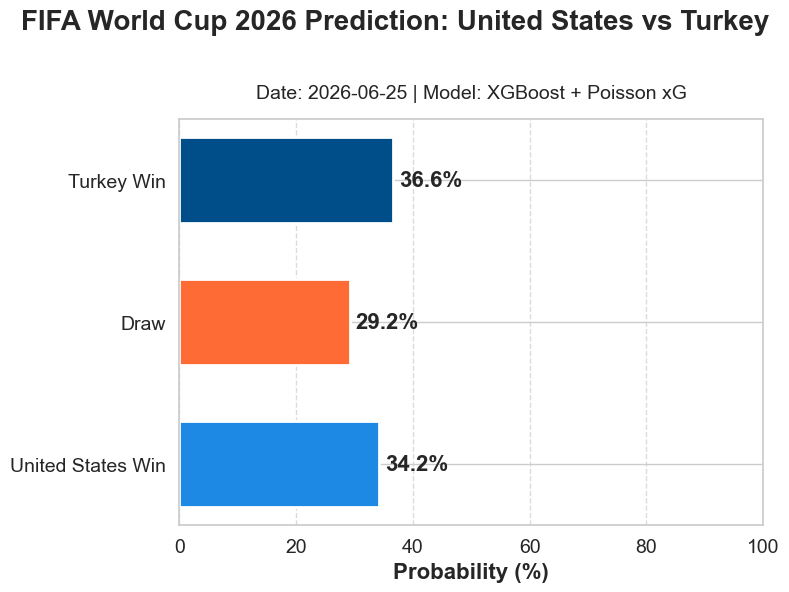

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\United_States_vs_Turkey_score.png


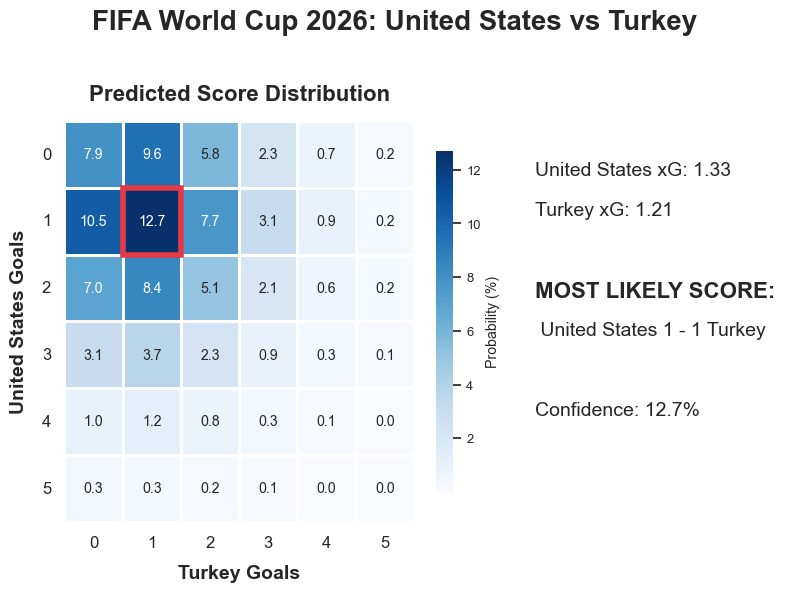

In [6]:
pred = predict_match("United States", "Turkey")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("United States", "Turkey", probs)
    generate_score_heatmap("United States", "Turkey", home_xg, away_xg)

---
## 6. Second Match: Paraguay vs Australia


Match Prediction: Paraguay vs Australia
Location: Neutral
--------------------------------------------------
Probabilities: Paraguay 26.2% | Draw 39.5% | Australia 34.3%
Expected Goals (xG): Paraguay 1.11 - 1.40 Australia
Most Likely Score: 1 - 1 (12.6% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Paraguay_vs_Australia_prob.png


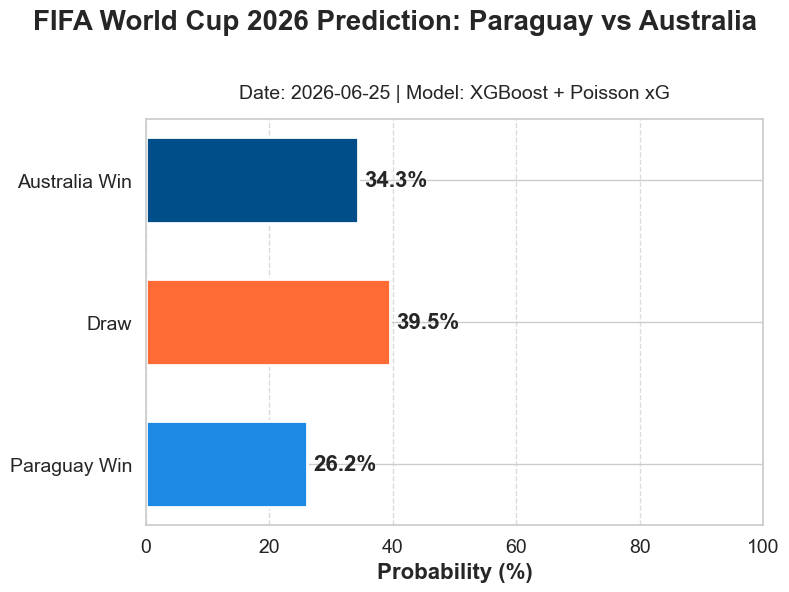

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Paraguay_vs_Australia_score.png


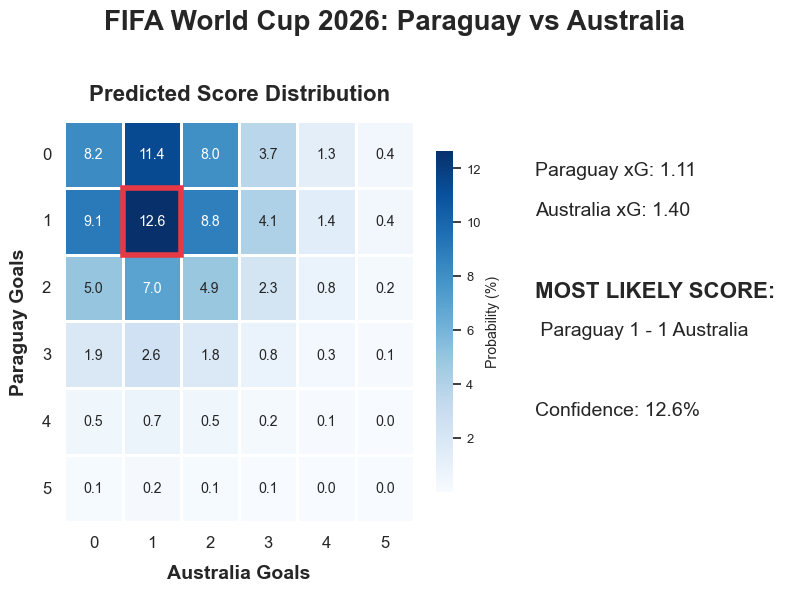

In [7]:
pred = predict_match("Paraguay", "Australia")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Paraguay", "Australia", probs)
    generate_score_heatmap("Paraguay", "Australia", home_xg, away_xg)

---
## 7. Third Match: Curaçao vs Ivory Coast


Match Prediction: Curaçao vs Ivory Coast
Location: Neutral
--------------------------------------------------
Probabilities: Curaçao 7.9% | Draw 20.5% | Ivory Coast 71.7%
Expected Goals (xG): Curaçao 0.79 - 2.03 Ivory Coast
Most Likely Score: 0 - 2 (12.3% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Curaçao_vs_Ivory_Coast_prob.png


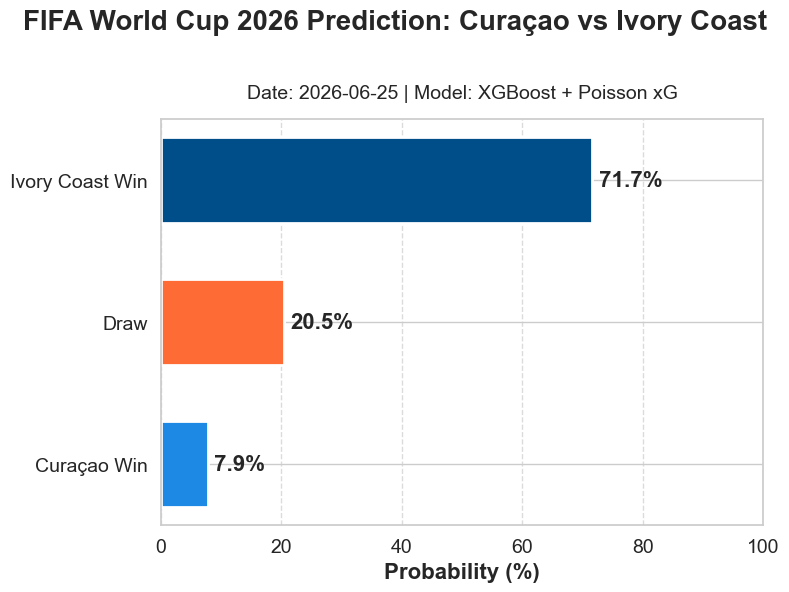

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Curaçao_vs_Ivory_Coast_score.png


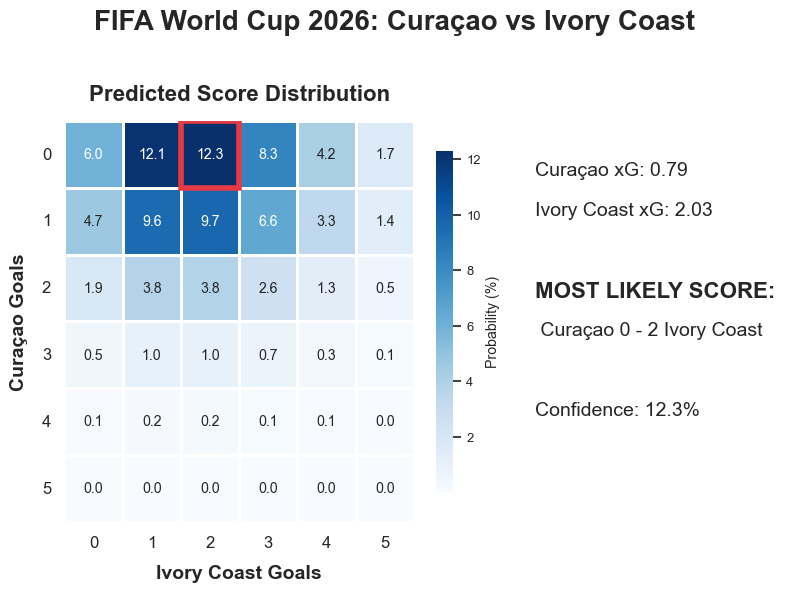

In [8]:
pred = predict_match("Curaçao", "Ivory Coast")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Curaçao", "Ivory Coast", probs)
    generate_score_heatmap("Curaçao", "Ivory Coast", home_xg, away_xg)

---
## 8. Fourth Match: Ecuador vs Germany


Match Prediction: Ecuador vs Germany
Location: Neutral
--------------------------------------------------
Probabilities: Ecuador 37.5% | Draw 29.6% | Germany 32.9%
Expected Goals (xG): Ecuador 1.34 - 1.33 Germany
Most Likely Score: 1 - 1 (12.3% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Ecuador_vs_Germany_prob.png


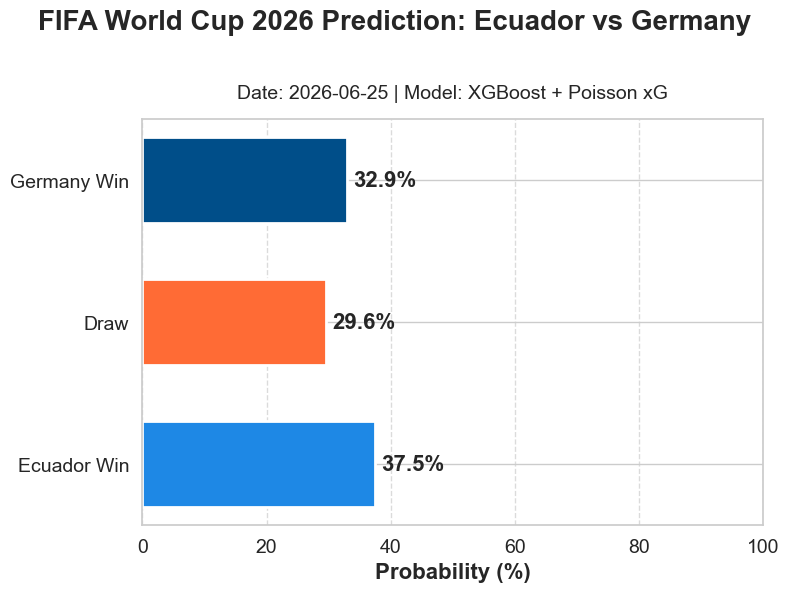

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Ecuador_vs_Germany_score.png


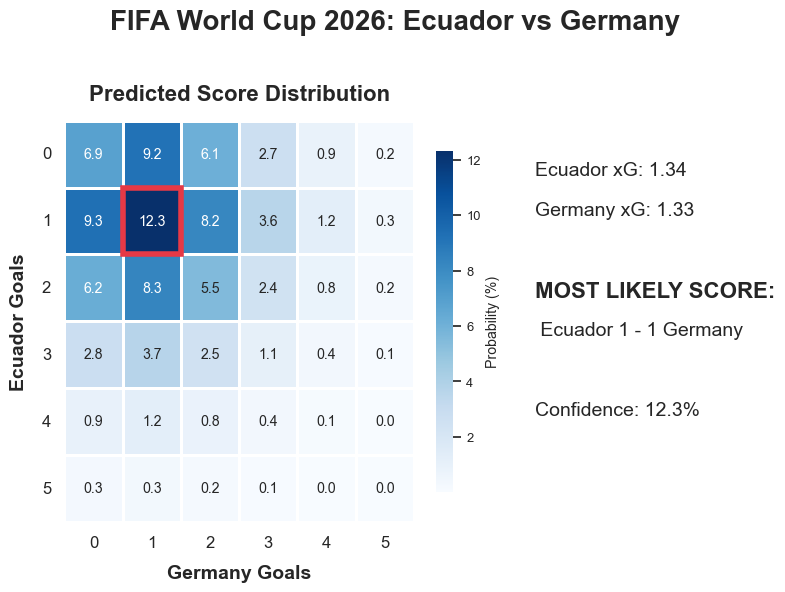

In [9]:
pred = predict_match("Ecuador", "Germany")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Ecuador", "Germany", probs)
    generate_score_heatmap("Ecuador", "Germany", home_xg, away_xg)

---
## 9. Fifth Match: Japan vs Sweden


Match Prediction: Japan vs Sweden
Location: Neutral
--------------------------------------------------
Probabilities: Japan 78.8% | Draw 13.4% | Sweden 7.8%
Expected Goals (xG): Japan 2.27 - 0.87 Sweden
Most Likely Score: 2 - 0 (11.2% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Japan_vs_Sweden_prob.png


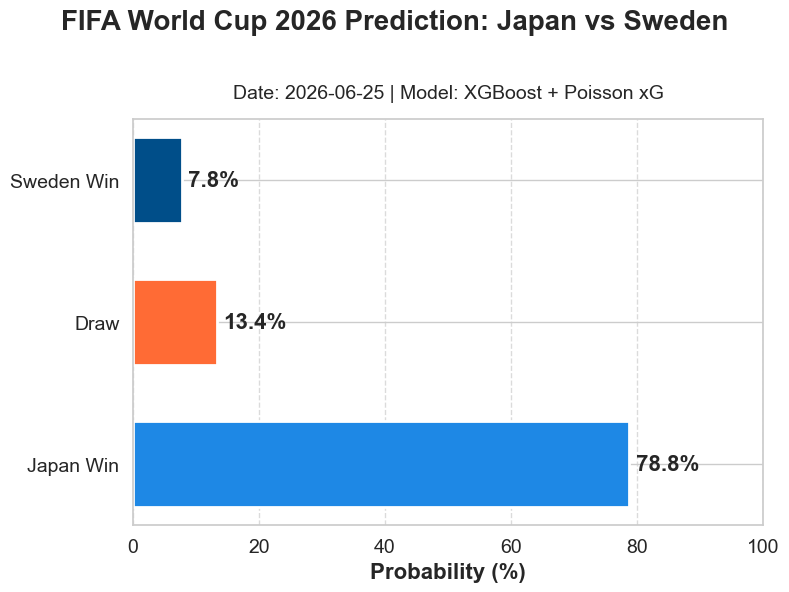

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Japan_vs_Sweden_score.png


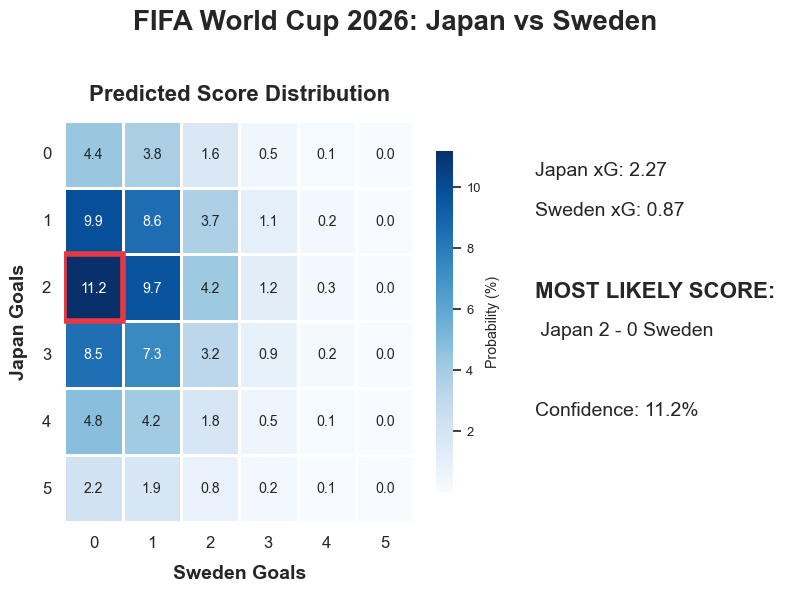

In [10]:
pred = predict_match("Japan", "Sweden")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Japan", "Sweden", probs)
    generate_score_heatmap("Japan", "Sweden", home_xg, away_xg)

---
## 10. Sixth Match: Tunisia vs Netherlands


Match Prediction: Tunisia vs Netherlands
Location: Neutral
--------------------------------------------------
Probabilities: Tunisia 11.3% | Draw 22.1% | Netherlands 66.5%
Expected Goals (xG): Tunisia 0.81 - 1.78 Netherlands
Most Likely Score: 0 - 1 (13.3% confidence)
--------------------------------------------------
Saved outcome chart: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Tunisia_vs_Netherlands_prob.png


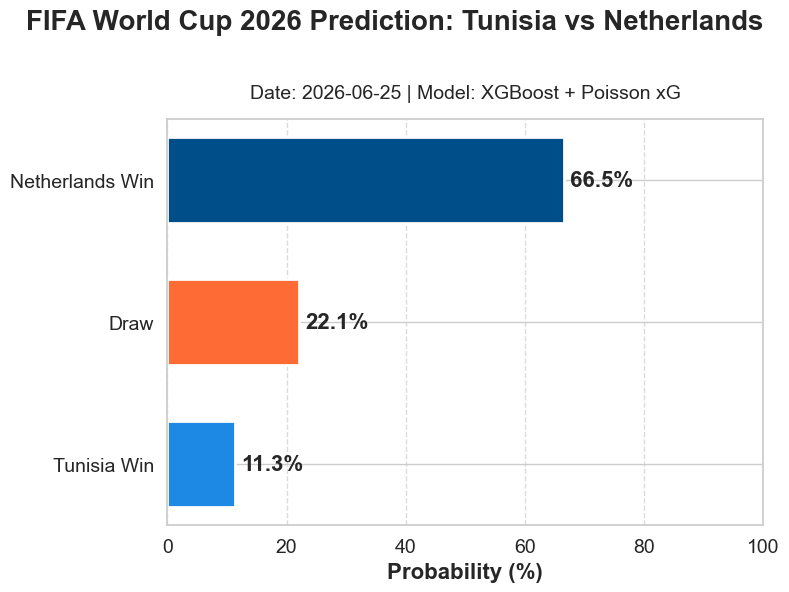

Score chart saved: c:\Users\nitindave\Desktop\FIFA 2026\visualizations_linkedin\Tunisia_vs_Netherlands_score.png


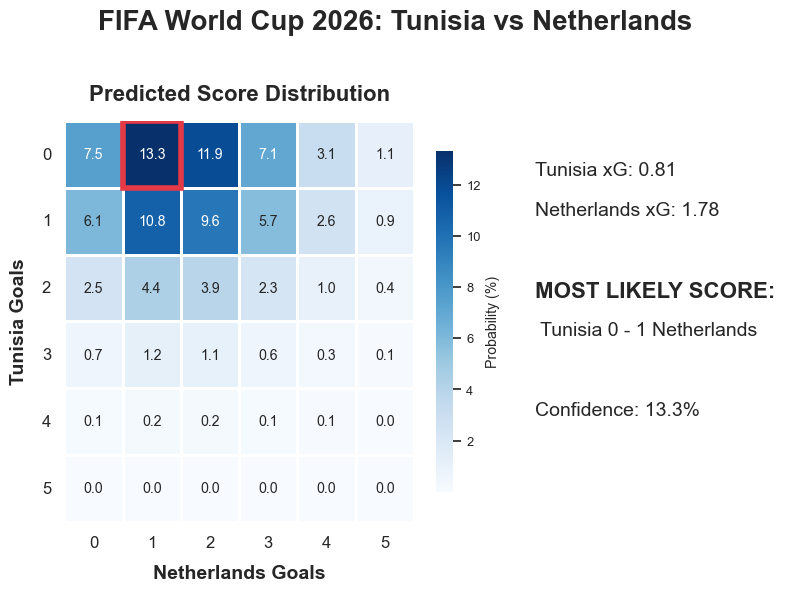

In [11]:
pred = predict_match("Tunisia", "Netherlands")
if pred:
    probs, (home_xg, away_xg) = pred['probs'], pred['xg']
    generate_outcome_chart("Tunisia", "Netherlands", probs)
    generate_score_heatmap("Tunisia", "Netherlands", home_xg, away_xg)

---
## Check Generated Files!

Check your project root directory's `visualizations_linkedin` folder to see your beautiful LinkedIn-ready charts!